# CME Futures: Label Engineering

Every model in this case study is trained to predict the label defined here, so an error
in it is silent where it is made and reaches every metric and every backtest after it.
This notebook picks the price series a forward return may be measured on, fixes the two
dates it is measured between, checks that every labelled row has an unbroken run of its
product's own trading sessions ahead of it, measures how much independent information
those rows carry, measures what a simple term-structure signal already earns against the
label, and writes the two label files the later stages read.

## Learning objectives

- Choose between the two price series a futures panel carries, and say which question
  each one answers
- Write a forward return as the two prices it is measured between, then check - rather
  than assert - that every labelled window covers an unbroken run of the product's own
  trading sessions
- Keep a diagnostic out of the held-out test period by filtering on the date each label's
  outcome becomes known, rather than on the date its signal is observed
- Measure how much a label sampled every session repeats itself, and turn a row count
  into the number of independent observations it is worth
- Measure what a simple term-structure signal already earns against the label, under a
  standard error that accounts for that repetition

## Book reference, prerequisites and artifacts

Chapter 7, Section 7.2. Reads the roll-adjusted daily settlement panel through
`load_cme_futures()`, whose coverage
[`01_feasibility_analysis`](01_feasibility_analysis.ipynb) establishes, and
`config/setup.yaml`, which declares the universe, the label set, the horizons and the
date the held-out test period begins. Writes `labels/fwd_ret_5d.parquet` and
`labels/fwd_ret_21d.parquet`. [`04_model_based_features`](04_model_based_features.ipynb)
and [`05_evaluation`](05_evaluation.ipynb) both read the primary file to score the
features they build against it, and the model notebooks read both files through
`utils/modeling.py`. All of them place their cross-validation folds on the timeline of
the label file itself rather than on the price series, so which rows land in these files
decides where the fold boundaries fall.

In [1]:
"""CME Futures: Label Engineering."""

import math
import warnings
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml
from IPython.display import display
from ml4t.diagnostic.metrics import compute_ic_hac_stats, cross_sectional_ic_series

from case_studies.utils.artifact_digest import value_digest, write_artifact
from case_studies.utils.label_diagnostics import effective_sample_size, panel_autocorrelation
from data import load_cme_futures
from utils.artifact_specs import resolve_label_horizon
from utils.paths import get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title, show_with_alt

warnings.filterwarnings("ignore")

CASE_STUDY_ID = "cme_futures"
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
LABELS_DIR = CASE_DIR / "labels"

Both parameters are unset by default, and both are read below. `START_DATE` trims the
history to a later start; `MAX_PRODUCTS` keeps only the first products in alphabetical
order. Either one shortens a run at the cost of a thinner panel: the rank correlation in
Section G and the cross-sectional dispersion in Section E both need a wide cross-section
on each session to mean anything.

In [2]:
MAX_PRODUCTS = None
START_DATE = None

## Configuration

Everything that defines a label is declared in `config/setup.yaml` and bound here. A
horizon or a boundary typed into a cell is a second copy of a value the rest of the
pipeline reads from the file, and the two drift apart the first time either is edited.

`resolve_label_horizon` prefers an explicit `labels.horizons` entry and falls back to the
cross-validation buffer. The two fields are separate, because the gap that keeps folds
independent need not equal the horizon an outcome resolves over; here they coincide, and
both are declared in trading sessions.

In [3]:
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

PRIMARY_LABEL = setup["labels"]["primary"]
LABEL_NAMES = [PRIMARY_LABEL, *setup["labels"].get("variants", [])]
VARIANT_LABEL = LABEL_NAMES[1]
HORIZONS = {
    name: int(resolve_label_horizon(CASE_STUDY_ID, name, setup).rstrip("Dd"))
    for name in LABEL_NAMES
}
PRIMARY_HORIZON = HORIZONS[PRIMARY_LABEL]
HOLDOUT_START = date.fromisoformat(setup["evaluation"]["holdout_start"])
# Two sessions carry one clearing venue's settlement file and not the other's; `setup.yaml`
# says which and why. Dropping them here keeps a forward return from being measured across a
# date on which half the universe has no settlement price.
EXCLUDED_SESSIONS = [
    date.fromisoformat(str(d)) for d in setup["universe"].get("excluded_sessions", [])
]
GROUPS = setup["universe"]["product_groups"]
SECTORS = {product: sector for sector, ps in GROUPS.items() for product in ps}
REBALANCE_STEP = setup["labels"]["rebalance_step"]

print(
    f"{PRIMARY_LABEL} is the primary label - the return over the next {PRIMARY_HORIZON}"
    f" trading sessions, and what every model here is trained to predict. {VARIANT_LABEL} is"
    f" the one variant, the same return over {HORIZONS[VARIANT_LABEL]} sessions.\nBoth are"
    f" traded off the same weekly rebalancing schedule, and the longer horizon is traded"
    f" less often: the backtest advances {REBALANCE_STEP[PRIMARY_LABEL]} slot per trade on"
    f" the primary and {REBALANCE_STEP[VARIANT_LABEL]} on the variant, so the variant"
    f" rebalances a third as often.\nSessions from"
    f" {HOLDOUT_START} on are the held-out test period, and a label belongs to it as soon as"
    f" its outcome falls there, so that is the boundary every diagnostic below stops at.\n"
    f"The universe is the fixed list of {len(SECTORS)} products the file declares, in"
    f" {len(GROUPS)} sectors."
)

fwd_ret_5d is the primary label - the return over the next 5 trading sessions, and what every model here is trained to predict. fwd_ret_21d is the one variant, the same return over 21 sessions.
Both are traded off the same weekly rebalancing schedule, and the longer horizon is traded less often: the backtest advances 1 slot per trade on the primary and 3 on the variant, so the variant rebalances a third as often.
Sessions from 2024-01-01 on are the held-out test period, and a label belongs to it as soon as its outcome falls there, so that is the boundary every diagnostic below stops at.
The universe is the fixed list of 30 products the file declares, in 7 sectors.


## A. The learning task

The hypothesis is cross-sectional and it is about the shape of each futures curve. Each
product trades as a series of contracts expiring on different dates, and their prices sit
at different levels; the **front contract** is the one nearest to expiry and the one this
strategy trades. Where the front contract trades above the next one along, the curve
slopes down and the market is paying to hold the product - **backwardation**; where the
front trades below the next, it slopes up and holding costs money - **contango**. The
claim is that products in backwardation out-earn products in contango over the following
week, ranked against each other rather than judged in isolation. The label is therefore a
forward price return on the front contract, and the strategy that consumes it goes long
the top-ranked products and short the bottom-ranked ones across the thirty.

The decision cadence comes from `setup.yaml`: a Friday settlement is observed, and the
resulting position is entered at Monday's open. That fixes the primary horizon at one
trading week. The variant asks whether the same curve signal still pays when the outcome
is measured twenty-one sessions out instead of five - a question about how long the signal
stays informative, and about the cost of trading it, rather than a second hypothesis. Both
are traded off the same weekly schedule, rebalanced at different rates. Labels are
sampled on every session rather than only on Fridays: that buys five times the rows at
the price of overlap, and Section F measures what they are worth.

## B. Preparation before the label

**Two price series, two jobs, and picking the wrong one is the mistake this dataset
invites.** Every row carries a raw traded settlement (`raw_close`) and a roll-continuous,
ratio-adjusted level (`adj_close`). A forward return has to ride the adjusted series:
ratio back-adjustment rescales the pre-roll history so that rolling from one contract to
the next does not register as a price move, and a return taken across a roll date on the
raw series would report the front-to-deferred basis gap as profit. A contemporaneous
term-structure quantity - the carry signal in Section G, and every curve feature in
[`03_financial_features`](03_financial_features.ipynb) - reads `raw_close` instead, because
differencing two *adjusted* contracts measures their accumulated roll history rather than
today's curve. Chapter 2's
[`06_futures_continuous`](../../02_financial_data_universe/06_futures_continuous.ipynb)
constructs the adjusted series.

The loader returns three contracts per product, indexed by `position`: 0 is the front
contract, 1 and 2 the next two along the curve. Only the front contract is labelled,
because it is the one the strategy trades, and it is separated out here rather than later:
`position` is part of the row's identity, so keeping one position removes whole series
rather than rows from inside one. No eligibility filter runs before the forward shift, and
that ordering matters: once rows are dropped from inside a series, a shift counts the rows
that survived, the horizon stops being measured in trading sessions, and the window
silently spans whatever was removed.

In [4]:
bars = load_cme_futures(products=sorted(SECTORS)).rename(
    {"session_date": "timestamp", "tenor": "position"}
)
bars = bars.filter(~pl.col("timestamp").is_in(EXCLUDED_SESSIONS))
if START_DATE is not None:
    bars = bars.filter(pl.col("timestamp") >= date.fromisoformat(START_DATE))
if MAX_PRODUCTS is not None:
    keep = sorted(bars["product"].unique().to_list())[:MAX_PRODUCTS]
    bars = bars.filter(pl.col("product").is_in(keep))
bars = bars.sort(["product", "position", "timestamp"]).with_columns(
    pl.col("product").replace_strict(SECTORS).alias("sector")
)
front = bars.filter(pl.col("position") == 0)

# Recorded as every label's `inputs`: a re-run against a refreshed download is
# otherwise indistinguishable from this one.
MARKET_DATA_DIGEST = value_digest(front, ["product", "position", "timestamp", "adj_close"])

print(f"{front['product'].n_unique()} products, {front.height:,} front-contract sessions")
print(f"Sessions {front['timestamp'].min()} to {front['timestamp'].max()}")
print(f"market_data digest: {MARKET_DATA_DIGEST}")

30 products, 113,476 front-contract sessions
Sessions 2011-01-03 to 2025-12-31
market_data digest: 68de71ceceb08816


These are the thirty products, grouped the way the exchange and the strategy group them.
The sectors are what the label has to be comparable across: a ranking model sees one
target column and does not know that a treasury note and a barrel of crude move on
different scales. Section E measures how far apart those scales are.

Two things in the table matter for what follows. `earliest_start` and `latest_start` agree
in every sector but equity index, where one product joins the panel six and a half years
after the other three - a shorter history that the label carries into every fold that
product appears in, and the reason equity index also has the widest spread between
`fewest_sessions` and `most_sessions`. Everywhere else that spread is one or two sessions,
but the level differs by more than a hundred sessions across sectors, because grain,
livestock and financial products keep different exchange holidays. There is no one calendar
to count a horizon against, so the horizon below is counted on each product's own
settlements, and Section D measures how far that stands up.

In [5]:
universe = (
    front.group_by("sector", "product")
    .agg(pl.col("timestamp").min().alias("start"), pl.len().alias("sessions"))
    .group_by("sector")
    .agg(
        pl.col("product").sort().str.join(" ").alias("products"),
        pl.col("start").min().alias("earliest_start"),
        pl.col("start").max().alias("latest_start"),
        pl.col("sessions").min().alias("fewest_sessions"),
        pl.col("sessions").max().alias("most_sessions"),
    )
    .sort("sector")
)
with pl.Config(tbl_rows=universe.height, tbl_width_chars=170, fmt_str_lengths=40):
    display(universe)

sector,products,earliest_start,latest_start,fewest_sessions,most_sessions
str,str,date,date,u32,u32
"""agriculture""","""ZC ZL ZM ZS ZW""",2011-01-03,2011-01-03,3772,3773
"""currencies""","""6A 6B 6C 6E 6J 6S""",2011-01-03,2011-01-03,3858,3858
"""energy""","""CL HO NG RB""",2011-01-03,2011-01-03,3868,3868
"""equity_index""","""ES NQ RTY YM""",2011-01-03,2017-07-10,2190,3867
"""livestock""","""GF HE LE""",2011-01-03,2011-01-03,3763,3764
"""metals""","""GC HG PL SI""",2011-01-03,2011-01-03,3867,3868
"""treasuries""","""ZB ZF ZN ZT""",2011-01-03,2011-01-03,3861,3862


## C. Label construction

A label is a statement about which two prices a position is opened and closed at. Written
once and applied at both horizons, this one is

$$r^{(h)}_{p,t} = \frac{A_{p,t+h}}{A_{p,t}} - 1$$

where $A$ is the ratio-adjusted settlement of product $p$'s front contract and $t+h$
counts $h$ **trading sessions for that product**. Chapter 7.2 calls this close-to-close:
both ends are settlement prices, and a position is treated as opened and closed at the same
moment of the session. `setup.yaml` places the strategy's actual execution at the following
Monday's open, so the label measures the move the strategy is trying to capture rather than
the amount it would collect after filling at a different price.

The denominator is guarded rather than clipped. A settlement can be non-positive - one
deferred crude oil contract in this panel settled below zero on 2020-04-20 - and dividing
by a floor clipped to some small positive number would manufacture an enormous return
where the right answer is that the quantity is undefined. The front contract this notebook
labels never goes non-positive, and Section D's reconciliation is what shows that rather
than asserting it.

Two bookkeeping columns are numbered here, on the complete session series, because both
mean something only before a row is dropped: `from_end` counts back from each product's
last session for Section D's boundary profile, and `session` numbers its sessions forward
so Section F's overlap statistics keep counting trading sessions once the null tail and
the holdout are filtered out. Neither reaches a label parquet, which selects four columns.

In [6]:
def forward_return(df: pl.DataFrame, horizon: int, name: str) -> pl.DataFrame:
    """Close-to-close return over `horizon` sessions, null where the window spans a hole."""
    base = pl.when(pl.col("adj_close") > 0).then(pl.col("adj_close"))
    holes_ahead = pl.col("_holes").shift(-horizon).over("product") - pl.col("_holes")
    return df.with_columns(
        pl.when(holes_ahead == 0)
        .then(pl.col("adj_close").shift(-horizon).over("product") / base - 1)
        .otherwise(None)
        .alias(name)
    )


# A session-to-session spacing above a long weekend plus an exchange holiday is a hole in
# the product's series, not a calendar effect. `_holes` counts them cumulatively, so a
# window spanning one is found by differencing the count at its two ends.
MAX_SESSION_GAP_DAYS = 5
spacing = (pl.col("timestamp") - pl.col("timestamp").shift(1).over("product")).dt.total_days()

labels_df = front.with_columns(
    (pl.len().over("product") - 1 - pl.int_range(pl.len()).over("product")).alias("from_end"),
    pl.int_range(pl.len()).over("product").alias("session"),
    (spacing > MAX_SESSION_GAP_DAYS).fill_null(False).cum_sum().over("product").alias("_holes"),
)
for label_name, horizon in HORIZONS.items():
    labels_df = forward_return(labels_df, horizon, label_name)

print(f"Constructed {', '.join(LABEL_NAMES)}")
gaps = labels_df.group_by("product").agg(pl.col("_holes").max()).filter(pl.col("_holes") > 0)
print(f"{gaps['_holes'].sum()} holes above {MAX_SESSION_GAP_DAYS} days, in {gaps.height} products")

Constructed fwd_ret_5d, fwd_ret_21d
3 holes above 5 days, in 3 products


## D. Window validity

A shift always returns something; the question is whether what it returns is the quantity
the label claims. Each property below fails silently and leaves plausible numbers behind,
so each is asserted rather than described.

The second assertion is a full reconciliation rather than a bound. Every row carrying no
label is attributed to exactly one cause - the tail of its product's series, a hole inside
the forward window, or a non-positive settlement at the anchor - and the four counts have
to sum to the height of the frame. A label crossing a product boundary, or a short label
masked by a longer one's null set, would break that identity.

The third assertion bounds the calendar span a window may cover, which is what makes the
hole rule falsifiable rather than a definition: $h$ trading sessions span about $7h/5$
calendar days on a five-session week, plus a week for exchange holidays. The rule fires on
one event, a ten-day break in the three livestock products in February 2012, and without
it the monthly label there would span more days than any holiday pattern can account for.

In [7]:
for label_name, horizon in HORIZONS.items():
    checked = labels_df.with_columns(
        (pl.col("timestamp").shift(-horizon).over("product") - pl.col("timestamp"))
        .dt.total_days()
        .alias("_span")
    )
    tail = pl.col("from_end") < horizon
    holed = pl.col("_holes").shift(-horizon).over("product") != pl.col("_holes")
    unpriced = ~tail & ~holed & (pl.col("adj_close") <= 0)
    causes = {"tail": tail, "hole in window": ~tail & holed, "no anchor price": unpriced}
    # 1. An incomplete forward window is null, never a value.
    assert checked.filter(tail)[label_name].null_count() == checked.filter(tail).height

    # 2. Labelled rows plus the three causes account for every row, each cause once.
    counts = {cause: checked.filter(cond).height for cause, cond in causes.items()}
    labelled = checked.drop_nulls(label_name)
    assert labelled.height + sum(counts.values()) == checked.height, (label_name, counts)

    # 3. No labelled window spans more calendar days than holidays alone can explain.
    tolerance = math.ceil(horizon * 7 / 5) + 7
    assert labelled.filter(pl.col("_span") > tolerance).height == 0, label_name

    # 4. No discrete label is derived from a null return - vacuous by dtype here, since
    #    this notebook writes continuous labels only.
    assert labels_df.schema[label_name] == pl.Float64, label_name

    unlabelled = ", ".join(f"{n:,} {cause}" for cause, n in counts.items())
    print(
        f"{label_name}: {labelled.height:,} labelled, spans up to {labelled['_span'].max()}d "
        f"against a {tolerance}d tolerance; unlabelled {unlabelled}"
    )

fwd_ret_5d: 113,311 labelled, spans up to 12d against a 14d tolerance; unlabelled 150 tail, 15 hole in window, 0 no anchor price
fwd_ret_21d: 112,783 labelled, spans up to 35d against a 37d tolerance; unlabelled 630 tail, 63 hole in window, 0 no anchor price


All four assertions read each product's settlements as its trading calendar. The panel
records settlements rather than opening hours, so that reading is an inference, and it is
worth measuring: a date the product traded but the file has no row for makes every window
across it cover one session more than the horizon names.

The panel carries its own evidence. If one product in a sector settled on a date, that
sector's market was open, so a second product in the same sector with no row on that date
is missing a settlement rather than closed for a holiday. Counting those dates, and the
labelled windows that run across one, bounds how far the horizon can be off; a count large
enough to matter would mean the panel has to be rebuilt before the label can be trusted. A
closure a whole sector shares is invisible to this test, and the calendar-span assertion
above is what catches the long ones.

In [8]:
grid = front.select("timestamp").unique().sort("timestamp").with_row_index("_grid")
marks = (
    front.group_by("product", "sector")
    .agg(pl.col("timestamp").min().alias("_from"), pl.col("timestamp").max().alias("_to"))
    .join(front.select("sector", "timestamp").unique(), on="sector")
    .filter(pl.col("timestamp").is_between(pl.col("_from"), pl.col("_to")))
    .join(front.select("product", "timestamp"), on=["product", "timestamp"], how="anti")
    .join(grid, on="timestamp")
    .select("product", pl.col("_grid").alias("_absent"))
)
positioned = labels_df.join(grid, on="timestamp").sort("product", "timestamp")

print(
    f"{marks.height} product-sessions have no settlement on a date another product in the "
    f"same sector settled, over {front.height:,} rows"
)
for label_name, horizon in HORIZONS.items():
    spanning = (
        positioned.with_columns(pl.col("_grid").shift(-horizon).over("product").alias("_end"))
        .drop_nulls(label_name)
        .join(marks, on="product")
        .filter(pl.col("_absent").is_between(pl.col("_grid") + 1, pl.col("_end")))
        .select("product", "timestamp")
        .unique()
    )
    print(f"  {label_name}: {spanning.height} labelled windows run across one of them")

12 product-sessions have no settlement on a date another product in the same sector settled, over 113,476 rows
  fwd_ret_5d: 50 labelled windows run across one of them
  fwd_ret_21d: 210 labelled windows run across one of them


Position zero below is each product's last session, position one the session before it, and
so on backwards. The share of products carrying a label has to be zero over exactly the
last `horizon` positions and one everywhere beyond them. Two failures that a count of valid
rows reports as healthy are visible here at a glance: a tail filled in with a fabricated
value instead of a null, which would lift the left end off the floor, and a short label
masked by a longer one's null set, which would move its cliff out to the longer horizon.
The figure reads only which labels are null and never a label's value, so it is drawn over
the whole panel rather than the development window.

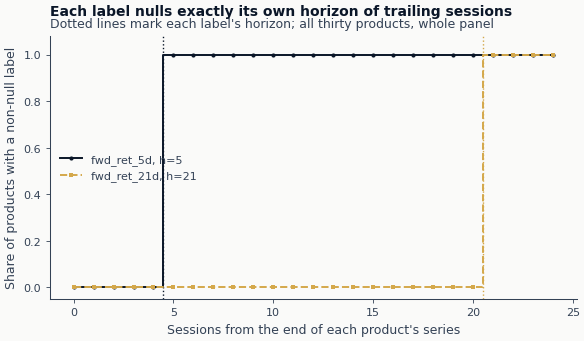

In [9]:
profile = (
    labels_df.filter(pl.col("from_end") <= max(HORIZONS.values()) + 3)
    .group_by("from_end")
    .agg([pl.col(name).is_not_null().mean().alias(name) for name in LABEL_NAMES])
    .sort("from_end")
)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for name, colour, fmt in zip(
    LABEL_NAMES, (COLORS["blue"], COLORS["amber"]), ("o-", "s--"), strict=True
):
    tag = f"{name}, h={HORIZONS[name]}"
    ax.plot(profile["from_end"], profile[name], fmt, ds="steps-mid", ms=3, c=colour, label=tag)
    ax.axvline(HORIZONS[name] - 0.5, color=colour, linestyle=":", lw=1)
ax.set_xlabel("Sessions from the end of each product's series")
ax.set_ylabel("Share of products with a non-null label")
ax.set_ylim(-0.05, 1.08)
add_message_title(
    ax,
    "Each label nulls exactly its own horizon of trailing sessions",
    subtitle="Dotted lines mark each label's horizon; all thirty products, whole panel",
)
ax.legend(loc="center left", frameon=False)
show_with_alt(fig, "Non-null label rate by position from the end of each product's series.")

## E. Distribution and base rate

What scale is the label, and does it mean the same thing across products and across
regimes? Everything from here through Section G is measured on the **development window**:
the sessions before the held-out test period, and only those whose label has already
resolved by the time that period opens. That second condition is the one that is easy to
get wrong. Filtering on the date a row is observed keeps rows observed in the last weeks of
2023 whose five- or twenty-one-session outcome lands in 2024, so the diagnostic reads
prices from inside the held-out period while looking as though it did not. The filter here
is on `_label_end`, the date the label's own window closes, which is the observation date
shifted forward by that label's horizon within the product.

The label files themselves keep every row, including the held-out ones: what is withheld is
what this notebook is allowed to look at, not what the later stages are given.

In [10]:
dev = {
    name: labels_df.with_columns(
        pl.col("timestamp").shift(-horizon).over("product").alias("_label_end")
    )
    .filter(pl.col("_label_end") < HOLDOUT_START)
    .drop_nulls(name)
    for name, horizon in HORIZONS.items()
}
for label_name, frame in dev.items():
    print(
        f"{label_name}: {frame.height:,} development rows, last one observed "
        f"{frame['timestamp'].max()} and resolved {frame['_label_end'].max()}"
    )

fwd_ret_5d: 97,921 development rows, last one observed 2023-12-21 and resolved 2023-12-29
fwd_ret_21d: 97,393 development rows, last one observed 2023-11-29 and resolved 2023-12-29


Both labels go on one axis with identical bins and a logarithmic count axis. A longer
horizon has to widen a return distribution, and the useful question is how: the two widths
alone would not say whether the monthly label spreads its body evenly or piles the extra
mass into the tails, and it is the tails that decide how much a squared-error model is
pulled around by a handful of rows. The axis is symmetric and narrower than either label's
range, so the rows outside it are counted below rather than drawn, and the log count axis
keeps the tail bins readable next to a centre that holds ten thousand rows.

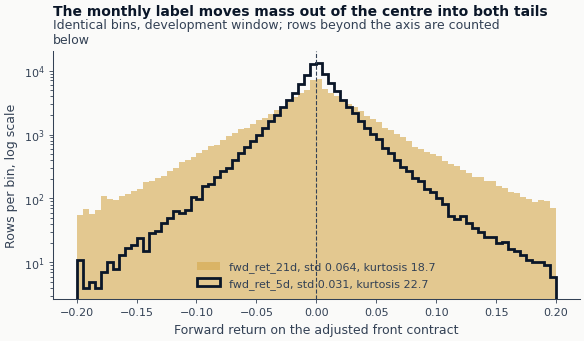

fwd_ret_5d: std 0.03138, kurtosis 22.72, 141 rows beyond the axis
fwd_ret_21d: std 0.06407, kurtosis 18.66, 1,405 rows beyond the axis
width ratio 2.04 against 2.05 under square-root-of-horizon scaling


In [11]:
bins = np.linspace(-0.20, 0.20, 81)
styles = {
    VARIANT_LABEL: dict(color=COLORS["amber"], alpha=0.6, zorder=1),
    PRIMARY_LABEL: dict(color=COLORS["blue"], histtype="step", lw=2, zorder=2),
}
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for name in (VARIANT_LABEL, PRIMARY_LABEL):
    series = dev[name][name]
    tag = f"{name}, std {series.std():.3f}, kurtosis {series.kurtosis():.1f}"
    ax.hist(series.to_numpy(), bins=bins, label=tag, **styles[name])
ax.axvline(0, color=COLORS["neutral"], linestyle="--", lw=0.8)
ax.set_yscale("log")
ax.set_xlabel("Forward return on the adjusted front contract")
ax.set_ylabel("Rows per bin, log scale")
add_message_title(
    ax,
    "The monthly label moves mass out of the centre into both tails",
    subtitle="Identical bins, development window; rows beyond the axis are counted below",
)
ax.legend(loc="lower center", frameon=False)
show_with_alt(fig, "Histograms of both labels on identical bins and a log count axis.")

std = {name: dev[name][name].std() for name in LABEL_NAMES}
for name in LABEL_NAMES:
    outside = dev[name].filter(pl.col(name).abs() > bins[-1]).height
    print(
        f"{name}: std {std[name]:.5f}, kurtosis {dev[name][name].kurtosis():.2f}, "
        f"{outside:,} rows beyond the axis"
    )
root_h = math.sqrt(HORIZONS[VARIANT_LABEL] / PRIMARY_HORIZON)
ratio = std[VARIANT_LABEL] / std[PRIMARY_LABEL]
print(f"width ratio {ratio:.2f} against {root_h:.2f} under square-root-of-horizon scaling")

Chapter 7.2 asks for the base rate to be tracked through time. For a continuous label
ranked across a cross-section, the quantity that has to be stable is the spread the model
ranks within: where it is not, the same rank correlation buys a different amount of
return. So the spread is measured across products within each session, and those daily
spreads are then averaged over the year - which keeps out the movement of the whole panel
from one session to the next, a quantity a ranking model never sees.

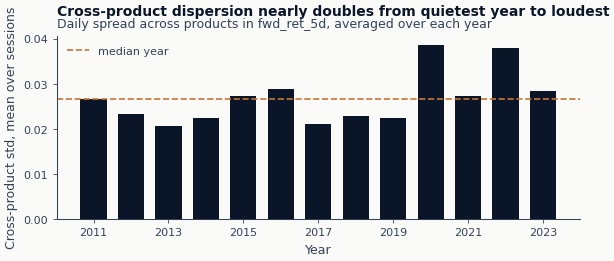

dispersion peaks at 3.9% in 2020 against 2.1% in 2013, a ratio of 1.86; median year 2.7%


In [12]:
annual = (
    dev[PRIMARY_LABEL]
    .group_by("timestamp")
    .agg(pl.col(PRIMARY_LABEL).std().alias("dispersion"))
    .with_columns(pl.col("timestamp").dt.year().alias("year"))
    .group_by("year")
    .agg(pl.col("dispersion").mean())
    .sort("year")
)
peak, low = (annual.sort("dispersion", descending=d).row(0, named=True) for d in (True, False))
median_dispersion = annual["dispersion"].median()

fig, ax = plt.subplots(figsize=FIGSIZE["single_wide"])
ax.bar(annual["year"], annual["dispersion"], color=COLORS["blue"], width=0.7)
ax.axhline(median_dispersion, color=COLORS["copper"], linestyle="--", lw=1.2, label="median year")
ax.set_xticks(annual["year"].to_list()[::2])
ax.set_xlabel("Year")
ax.set_ylabel("Cross-product std, mean over sessions")
add_message_title(
    ax,
    "Cross-product dispersion nearly doubles from quietest year to loudest",
    subtitle=f"Daily spread across products in {PRIMARY_LABEL}, averaged over each year",
)
ax.legend(loc="upper left", frameon=False)
show_with_alt(fig, "Annual mean of the daily cross-product dispersion of the primary label.")

print(
    f"dispersion peaks at {peak['dispersion']:.1%} in {peak['year']:.0f} against "
    f"{low['dispersion']:.1%} in {low['year']:.0f}, a ratio of "
    f"{peak['dispersion'] / low['dispersion']:.2f}; median year {median_dispersion:.1%}"
)

The same spread taken within each sector is what argues against fitting on a single pooled
scale. Energy and treasuries carry the same label column, and the widths that column takes
in each are not comparable, so a squared-error model fitted across the pool spends most of
its capacity on the loud sectors and treats a large move in a treasury note as noise. That
is the argument for ranking products against each other, which is what the strategy trades
on, and for the within-sector normalization `03_financial_features` applies to its
features.

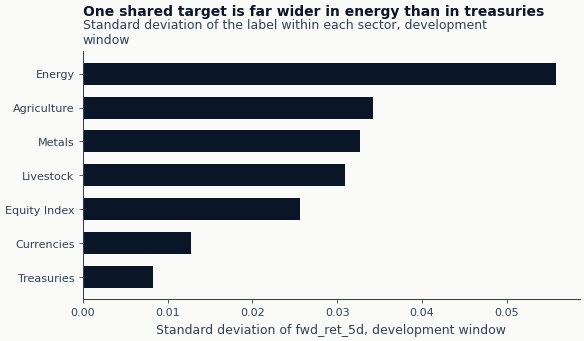

on one shared label the standard deviation runs from 0.008213 in treasuries to 0.055872 in energy, a factor of 6.8


In [13]:
sector_std = (
    dev[PRIMARY_LABEL]
    .group_by("sector")
    .agg(pl.col(PRIMARY_LABEL).std().alias("std"))
    .with_columns(pl.col("sector").str.replace_all("_", " ").str.to_titlecase().alias("label"))
    .sort("std")
)
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.barh(sector_std["label"], sector_std["std"], color=COLORS["blue"], height=0.65)
ax.set_xlabel(f"Standard deviation of {PRIMARY_LABEL}, development window")
add_message_title(
    ax,
    "One shared target is far wider in energy than in treasuries",
    subtitle="Standard deviation of the label within each sector, development window",
)
show_with_alt(fig, "Standard deviation of the primary label by product sector.")

narrow, wide = sector_std.row(0, named=True), sector_std.row(-1, named=True)
print(
    f"on one shared label the standard deviation runs from {narrow['std']:.6f} in "
    f"{narrow['sector']} to {wide['std']:.6f} in {wide['sector']}, a factor of "
    f"{wide['std'] / narrow['std']:.1f}"
)

On the development window the weekly label has a standard deviation of 0.03138 and the
monthly label 0.06407, a ratio of 2.04 against the 2.05 that square-root-of-horizon
scaling implies. One target column, two ways of not being one scale: across products the
daily spread peaks at 3.9% in 2020 against a 2.7% median year, and within sector the weekly
label runs from 0.008213 in treasuries to 0.055872 in energy, so the widest sector is 6.8x
the narrowest.

## F. Overlap and effective sample size

A label is written on every session, but a five-session return covers five sessions, so
today's label and tomorrow's are built from four of the same daily moves. Rows that share
their inputs are not separate evidence, and a statistic that counts them as separate
understates its own uncertainty. Two measurements say how much of that is going on.

The first is the autocorrelation of the label against its own lag. If the only thing
connecting one row to the next is the shared part of their windows, the correlation should
fall off in a straight line and reach zero at the lag where the sharing stops - the label's
own horizon. Anything left beyond that lag is the product's returns genuinely predicting
themselves, which is a different phenomenon.

The second turns the row count into a number of independent observations. Chapter 7.2
weights each row by the share of its forward window that no other label's window also
covers - its average uniqueness - and sums the weights. A five-session label written every
session shares four of its five moves with each neighbour on either side, so each weight
tends to one fifth and the sum tends to one fifth of the rows. `effective_sample_size`
computes this per product, because only a product's own windows overlap each other.

Both are counted on `session`, which numbers each product's settlements in order along the
full series, rather than on position among the rows that reach the development frame. That
frame is missing the rows the hole rule nulled and the trailing rows with no window at all,
and counting positions among the survivors would make the two rows either side of such a
gap look adjacent - pairing windows that in fact share nothing.

Neither number sets the **purge gap**: the run of sessions dropped between a training fold
and the validation fold after it, so that no training row's outcome is realised inside the
window the model is scored on. That gap is the label's horizon, by construction. What these
two numbers say is how much evidence the training rows that remain actually carry.

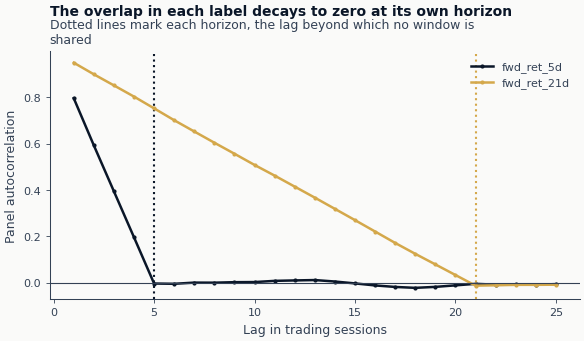

fwd_ret_5d: N=97,921, N_eff=19,611, ratio 0.2003 against 0.2000 for windows overlapping this fully; autocorrelation 0.797 at lag one, -0.004 at its horizon


fwd_ret_21d: N=97,393, N_eff=4,669, ratio 0.0479 against 0.0476 for windows overlapping this fully; autocorrelation 0.950 at lag one, -0.013 at its horizon


In [14]:
max_lag = HORIZONS[VARIANT_LABEL] + 4
acf = {
    name: panel_autocorrelation(
        dev[name], name, max_lag=max_lag, bar_col="session", entity_col="product"
    )
    for name in LABEL_NAMES
}

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
lags = np.arange(1, max_lag + 1)
for name, colour in zip(LABEL_NAMES, (COLORS["blue"], COLORS["amber"]), strict=True):
    ax.plot(lags, acf[name], "o-", ms=3, c=colour, lw=1.8, label=name)
    ax.axvline(HORIZONS[name], color=colour, linestyle=":", lw=1.5)
ax.axhline(0, color=COLORS["neutral"], lw=0.8)
ax.set_xlabel("Lag in trading sessions")
ax.set_ylabel("Panel autocorrelation")
add_message_title(
    ax,
    "The overlap in each label decays to zero at its own horizon",
    subtitle="Dotted lines mark each horizon, the lag beyond which no window is shared",
)
ax.legend(loc="upper right", frameon=False)
show_with_alt(fig, "Panel autocorrelation of both labels against lag in trading sessions.")

for label_name, horizon in HORIZONS.items():
    n_rows, n_eff = effective_sample_size(
        dev[label_name], horizon=horizon, bar_col="session", entity_col="product"
    )
    print(
        f"{label_name}: N={n_rows:,}, N_eff={n_eff:,.0f}, ratio {n_eff / n_rows:.4f} against "
        f"{1 / horizon:.4f} for windows overlapping this fully; autocorrelation "
        f"{acf[label_name][0]:.3f} at lag one, {acf[label_name][horizon - 1]:.3f} at its horizon"
    )

The weekly label's 97,921 development rows carry 19,611 effective observations, a ratio of
0.2003 against the 0.2000 a fully overlapped five-session window implies; the monthly
label's 97,393 rows carry 4,669, a ratio of 0.0479 against 0.0476. Both sit just above the
reference value because each product's series has two ends: the windows there overlap fewer
neighbours than an interior one does, and the reference assumes every window is full.
Autocorrelation falls from 0.797 at lag one to -0.004 at lag five for the weekly label, and
from 0.950 to -0.013 at lag twenty-one for the monthly one - a straight line to zero at
each label's own horizon, and nothing left beyond it.

## G. Baseline floor

Before any feature is built, one signal is measured against the primary label so that a
later improvement can be read against something. The signal is the **carry** the hypothesis
in Section A names: how far the front contract sits from the next one along, as a fraction
of the front price,

$$c_{p,t} = \frac{F^{(0)}_{p,t} - F^{(1)}_{p,t}}{F^{(0)}_{p,t}}$$

where the superscript is `position`, so $F^{(0)}$ is the front contract and $F^{(1)}$ the
next one along, and both are **raw** settlements: a difference between two adjusted series
would measure their accumulated roll history rather than today's curve. The quantity is
positive in backwardation and negative in contango.
[`03_financial_features`](03_financial_features.ipynb) builds the same spread as its
`carry_pct` feature, on a twelve-times-larger scale. Multiplying by a positive constant
leaves every within-session ranking untouched, so it changes nothing the score below
reads; it does mean the two notebooks print the quantity at different magnitudes.

The score is the **information coefficient**: the rank correlation between the signal and
the label, computed across the products quoted on each session and then averaged over
sessions. Ranking within a session is what the strategy does, so scoring it that way is
what a ranking model is answerable for. A session is scored only if at least half the usual
number of products are quoted on it - a fraction rather than a fixed count, so the rule
means the same thing on a universe of a different size - and a session below that floor
contributes nothing to the average.

The standard error on that average is HAC-adjusted: heteroskedasticity- and
autocorrelation-consistent, the Newey-West estimator, which widens the error bar when
neighbouring observations carry the same information. It is needed here for the reason
Section F measured. Five consecutive sessions of a five-session label are largely one
week's return seen five times, and the plain standard error counts them as five independent
readings. Both statistics are printed below, so the size of that correction is visible.

In [15]:
second = bars.filter(pl.col("position") == 1).select(
    ["product", "timestamp", pl.col("raw_close").alias("_next_close")]
)
baseline = (
    dev[PRIMARY_LABEL]
    .join(second, on=["product", "timestamp"], how="inner")
    .with_columns(
        pl.when(pl.col("raw_close") > 0)
        .then((pl.col("raw_close") - pl.col("_next_close")) / pl.col("raw_close"))
        .alias("carry")
    )
    .drop_nulls("carry")
)
min_obs = int(baseline.group_by("timestamp").len()["len"].median() // 2)

ic = cross_sectional_ic_series(
    baseline,
    baseline,
    pred_col="carry",
    ret_col=PRIMARY_LABEL,
    date_col="timestamp",
    entity_col="product",
    min_obs=min_obs,
).sort("timestamp")  # the HAC autocovariances are meaningless in any other order
stats = compute_ic_hac_stats(ic, ic_col="ic", label_horizon=PRIMARY_HORIZON)

print(
    f"Carry against {PRIMARY_LABEL} on {baseline.height:,} of the "
    f"{dev[PRIMARY_LABEL].height:,} development rows; the rest have no second contract quoted"
    f"\n  {stats['n_periods']:,} of {ic.height:,} sessions scored, the others below the "
    f"{min_obs}-product floor; mean IC {stats['mean_ic']:.4f}"
    f"\n  HAC t {stats['t_stat']:.2f} on {stats['effective_lags']} Bartlett lags, "
    f"naive t {stats['naive_t_stat']:.2f}, p {stats['p_value']:.3g}"
)

Carry against fwd_ret_5d on 96,062 of the 97,921 development rows; the rest have no second contract quoted
  3,337 of 3,350 sessions scored, the others below the 14-product floor; mean IC 0.0069
  HAC t 0.87 on 8 Bartlett lags, naive t 1.61, p 0.387


Carry earns a mean information coefficient of 0.0069 against the weekly label, positive as
the backwardation hypothesis implies, over the 3,337 of 3,350 development sessions that
have at least 14 products quoted. Under the plain standard error that is a t-statistic of
1.61; the Newey-West rule picks 8 lags here, above the four the horizon alone requires, and
the HAC statistic is 0.87 with a p-value of 0.387. So the level any feature has to beat is
a mean IC of 0.0069, and this evidence cannot separate that level from zero.

## H. Artifacts and the audit record

Each label goes to its own parquet file, and beside each one a small JSON file called a
**digest sidecar**. Its job is to make a stored artifact answer the question "is this the
same data I had last time" without anyone reading the parquet, and to say where the data
came from. It carries a hash of the values in the file, which changes if any value changes
but not if the rows are merely reordered; the number of rows; the columns that identify a
row; the notebook that wrote it; and, under `inputs`, the hash of the price data the label
was built from. That last field is the one that distinguishes a re-run against the same
download from a re-run against a refreshed one, which is otherwise invisible.

A row is identified by its date, its product and its `position`. `position` is constant at
zero in these two files, and it stays in the key anyway because it is what says the label
describes the front contract and not one of the deferred ones.

In [16]:
for label_name in LABEL_NAMES:
    keys = ["timestamp", "product", "position"]
    record = write_artifact(
        labels_df.select([*keys, label_name]).drop_nulls(),
        LABELS_DIR / f"{label_name}.parquet",
        keys=keys,
        written_by="02_labels",
        inputs={"market_data": MARKET_DATA_DIGEST},
    )
    print(f"{label_name}.parquet: {record['n_rows']:,} rows, digest {record['digest']}")

fwd_ret_5d.parquet: 113,311 rows, digest 67aa2a4d3b6338f6
fwd_ret_21d.parquet: 112,783 rows, digest 0aca0d5622a8270c


The record Chapter 7.2 requires to close a label definition, one row per label, built from
the values computed above rather than written by hand. The `consumed by` line is where the
label goes next: `04_model_based_features` and `05_evaluation` both score the features they
build against the primary label, and the model notebooks read both files through
`utils/modeling.py`, one training run per label.

In [17]:
readers = {
    PRIMARY_LABEL: "04_model_based_features.py and 05_evaluation.py, then the model notebooks",
    VARIANT_LABEL: "the model notebooks through utils/modeling.py, as the second label",
}
print("\nLabel audit record")
for label_name, horizon in HORIZONS.items():
    frame = dev[label_name]
    print(
        f"\n{label_name}\n  anchor       ratio-adjusted front-contract settlement at t"
        f"\n  horizon      {horizon} trading sessions on the product's own calendar"
        f"\n  resolution   fixed at t+h; daily settlements need no intraday tie-break"
        f"\n  overlap      {horizon - 1} sessions shared by consecutive rows"
        f"\n  base rate    mean {frame[label_name].mean():+.5f}, std {frame[label_name].std():.5f}"
        f"\n  consumed by  {readers[label_name]}"
    )


Label audit record

fwd_ret_5d
  anchor       ratio-adjusted front-contract settlement at t
  horizon      5 trading sessions on the product's own calendar
  resolution   fixed at t+h; daily settlements need no intraday tie-break
  overlap      4 sessions shared by consecutive rows
  base rate    mean +0.00031, std 0.03138
  consumed by  04_model_based_features.py and 05_evaluation.py, then the model notebooks

fwd_ret_21d
  anchor       ratio-adjusted front-contract settlement at t
  horizon      21 trading sessions on the product's own calendar
  resolution   fixed at t+h; daily settlements need no intraday tie-break
  overlap      20 sessions shared by consecutive rows
  base rate    mean +0.00118, std 0.06407
  consumed by  the model notebooks through utils/modeling.py, as the second label


## Key takeaways

1. **On a futures panel, decide which price series answers which question before writing
   anything.** A return has to ride the roll-adjusted series or a roll registers as
   profit; a curve quantity has to ride the raw one or it measures accumulated roll
   history. The two look interchangeable and are not.
2. **Account for every row that carries no label, rather than counting the ones that do.**
   An incomplete window at the end of a series, a break inside the window and a window that
   runs off the end of one product into the next all produce plausible numbers without
   raising anything, and a reconciliation that has to add up to the height of the frame is
   what catches them.
3. **Decide what a diagnostic may see by the date the outcome is known, not the date the
   signal is observed.** A row observed before the test period whose outcome resolves inside
   it belongs to the test period, so the usable boundary is the boundary minus the horizon,
   counted on each product's own sessions.
4. **A row count overstates the evidence when forward windows overlap.** The effective count
   says by how much. It does not set the purge gap between folds; the forward window does.
5. **Check that one target column means the same thing everywhere before fitting on it.**
   The spread of this label across sectors covers a factor of seven, which is the argument
   for ranking products against each other rather than regressing on a pooled scale.

**Known limitations.** Close-to-close is not the Monday-open execution the backtest fills
at, and nothing here measures that gap. The universe is a fixed thirty-product list rather
than a liquidity screen applied point in time. The check on window completeness rests on
each product's own settlements standing in for its trading calendar, which Section D bounds
but cannot confirm: an absence that a product's whole sector shares is indistinguishable
from a holiday unless it runs longer than the calendar-span assertion tolerates. The
baseline is one signal, built from the nearest two contracts only.

**Next**: [`03_financial_features`](03_financial_features.ipynb) builds the carry,
momentum, seasonal and composite features from the same settlement panel, and
[`05_evaluation`](05_evaluation.ipynb) is where they first meet the primary label written
here.